                                    College Name       Location  \
0       Andhra University College of Engineering  Visakhapatnam   
1                   JNTUA College of Engineering      Anantapur   
2                     SVU College of Engineering       Tirupati   
3                    GMR Institute of Technology          Rajam   
4  Gayatri Vidya Parishad College of Engineering  Visakhapatnam   

       Principal Name      Principal Email ID Placement Officer Name  \
0   Dr. K. Rajasekhar   principal@auce.edu.in        Mr. P. Srinivas   
1  Dr. G. Venkata Rao   principal@jntua.ac.in         Ms. S. Lavanya   
2       Dr. M. Ramesh    principal@svu.edu.in          Mr. K. Harish   
3       Dr. B. Suresh  principal@gmrit.edu.in            Ms. Deepika   
4         Dr. V. Raju   principal@gvpce.ac.in           Mr. S. Kiran   

  Placement Officer Email ID                   Courses Offered  \
0     placements@auce.edu.in  CSE, ECE, EEE, Mechanical, Civil   
1      placement@jntua.ac.in    

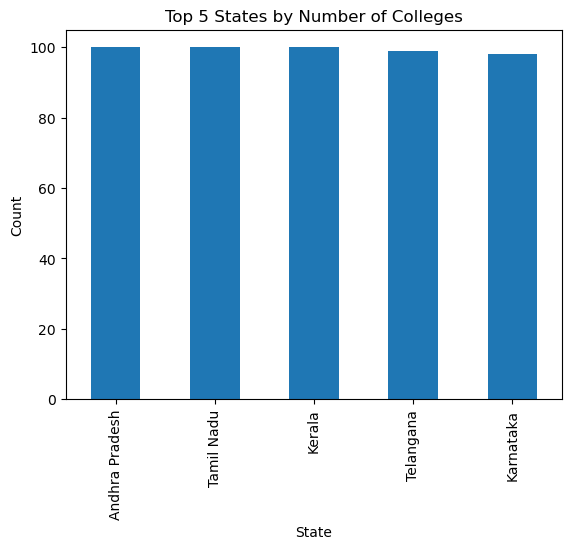

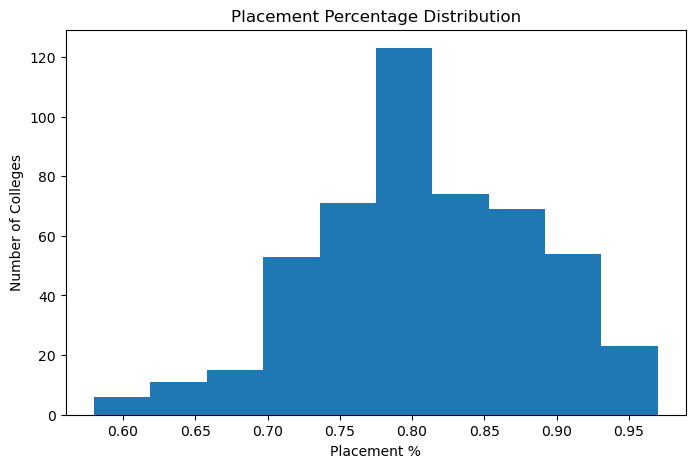

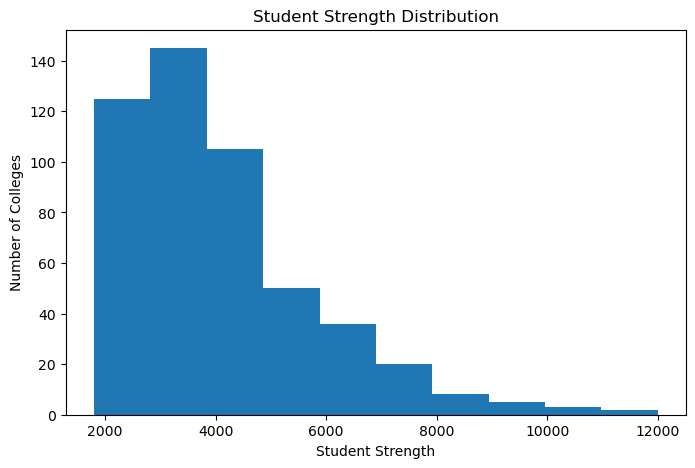


Top 10 Colleges
                                          College Name  College Score
113            SRM Institute of Science and Technology          1.685
301                                     PES University          1.685
187                           SASTRA Deemed University          1.480
6                                        KL University          1.475
342              Reva University School of Engineering          1.460
118                         Amrita Vishwa Vidyapeetham          1.435
303               M.S. Ramaiah Institute of Technology          1.430
204  VNR Vignana Jyothi Institute of Engineering an...          1.380
112     Sathyabama Institute of Science and Technology          1.375
302                         BMS College of Engineering          1.375

Project Completed Successfully!
Cleaned file saved as cleaned_college_data.xlsx


In [6]:
import pandas as pd

df = pd.read_excel(r"C:\Users\NIKITHA\Downloads\500 south colleges .xlsx")

print(df.head())

print(df.head())

# Display first 5 rows
print("First 5 Rows")
print(df.head())

# Dataset information
print("\nShape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing numeric values with median
numeric_columns = df.select_dtypes(include=np.number).columns
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Fill missing text values with "Unknown"
text_columns = df.select_dtypes(include="object").columns
for col in text_columns:
    df[col] = df[col].fillna("Unknown")

# Summary statistics
print("\nSummary Statistics")
print(df.describe())

# Government vs Private Colleges
if "College Type" in df.columns:
    type_count = df["College Type"].value_counts()

    print("\nGovernment vs Private")
    print(type_count)

    type_count.plot(kind="pie", autopct="%1.1f%%")
    plt.title("Government vs Private Colleges")
    plt.ylabel("")
    plt.show()

# Top 5 States
if "State" in df.columns:
    top_states = df["State"].value_counts().head(5)

    print("\nTop 5 States")
    print(top_states)

    top_states.plot(kind="bar")
    plt.title("Top 5 States by Number of Colleges")
    plt.xlabel("State")
    plt.ylabel("Count")
    plt.show()

# Placement Distribution
if "Placement %" in df.columns:
    plt.figure(figsize=(8,5))
    plt.hist(df["Placement %"], bins=10)
    plt.title("Placement Percentage Distribution")
    plt.xlabel("Placement %")
    plt.ylabel("Number of Colleges")
    plt.show()

# Student Strength Distribution
if "Student Strength" in df.columns:
    plt.figure(figsize=(8,5))
    plt.hist(df["Student Strength"], bins=10)
    plt.title("Student Strength Distribution")
    plt.xlabel("Student Strength")
    plt.ylabel("Number of Colleges")
    plt.show()

# College Score
if "Placement %" in df.columns and "Student Strength" in df.columns:
    df["College Score"] = (
        df["Placement %"] * 0.5 +
        df["Student Strength"] * 0.0001
    )

    top_score = df[["College Name", "College Score"]].sort_values(
        by="College Score",
        ascending=False
    ).head(10)

    print("\nTop 10 Colleges")
    print(top_score)

# Save cleaned dataset
df.to_excel("cleaned_college_data.xlsx", index=False)

print("\nProject Completed Successfully!")
print("Cleaned file saved as cleaned_college_data.xlsx")